In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?

def build_dataset(words): 
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [5]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())


In [17]:
import torch
import torch.nn.functional as F

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

class Linear: 
    def __init__(self, fan_in, fan_out, bias=True): 
        self.weight = torch.randn((fan_in, fan_out), device=device) / fan_in**0.5
        self.bias = torch.zeros(fan_out, device=device) if bias else None
    
    def __call__(self, x): 
        self.out = x @ self.weight 
        if self.bias is not None: 
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([self.bias] if self.bias is not None else [])


class BatchNorm1d: 
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        self.gamma = torch.ones(dim, device=device)
        self.beta = torch.zeros(dim, device=device)
        self.running_mean = torch.zeros(dim, device=device)
        self.running_var = torch.ones(dim, device=device)
    
    def __call__(self, x): 
        if self.training: 
            if x.ndim == 2: 
                dim = 0
            elif x.ndim == 3: 
                dim = (1, 0)
            else: 
                raise ValueError("Unknown dimensions")
            mean = x.mean(dim, keepdims=True)
            var  = x.var(dim, keepdims=True)
            self.out = self.gamma * ((x - mean) / (torch.sqrt(var + self.eps))) + self.beta
            with torch.no_grad(): 
                self.running_mean = ((1 - self.momentum) * self.running_mean) + (self.momentum * mean.squeeze())
                self.running_var = ((1 - self.momentum) * self.running_var) + (self.momentum * var.squeeze())
            return self.out
        else: 
            self.out = self.gamma * ((x - self.running_mean) / (torch.sqrt(self.running_var + self.eps))) + self.beta
            return self.out
    
    def parameters(self): 
        return [self.gamma, self.beta]


class Tanh:         
    def __call__(self, x): 
        self.out = torch.tanh(x)
        return self.out
    def parameters(self): 
        return []
    

class Embedding: 
    def __init__(self, num_embeddings, embeddings_dim): 
        self.weight = torch.randn(num_embeddings, embeddings_dim, device=device)
    
    def __call__(self, ix): 
        self.out = self.weight[ix]
        return self.out
    
    def parameters(self): 
        return [self.weight]


class Residual:
    def __init__(self, layers):
        self.layers = layers
    
    def __call__(self, x):
        out = x
        for layer in self.layers:
            out = layer(out)
        self.out = out + x
        return self.out
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    
    
class Flatten:
    def __call__(self, x):
        self.out = x.view(x.shape[0], -1)
        return self.out
    def parameters(self):
        return []
    

class Sequential: 
    def __init__(self, layers): 
        self.layers = layers
    
    def __call__(self, x): 
        for layer in self.layers: 
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self): 
        return [p for layer in self.layers for p in layer.parameters()]

Using device: mps


In [9]:
Xtr = Xtr.to(device)
Ytr = Ytr.to(device)

In [32]:
def train(model, name, Xtr, Ytr, n_steps=50_000):
    params = model.parameters()
    for p in params:
        p.requires_grad = True
    
    losses = []
    ud = []  # update to data ratios
    
    for step in range(n_steps):
        ix = torch.randint(0, Xtr.shape[0], (32,), device=device)
        xb, yb = Xtr[ix], Ytr[ix]
        
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        
        for p in params:
            p.grad = None
        loss.backward()
        
        lr = 0.1 if step < 150_000 else 0.01
        
        # Track update ratios before updating
        if step % 10000 == 0:
            with torch.no_grad():
                ud.append([
                    (lr * p.grad.std() / p.data.std()).log10().item()
                    for p in params
                ])
        
        for p in params:
            p.data -= lr * p.grad
        
        losses.append(loss.item())
        
        if step % 10000 == 0:
            print(f"[{name}] step {step:6d} | loss {loss.item():.4f}")
    
    return losses, ud

In [34]:
n_embd = 10
n_hidden = 200
vocab_size = 27
block_size = 8  # or whatever you used

plain_model = Sequential([
    Embedding(vocab_size, n_embd),
    Flatten(),
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])


In [35]:
plain_losses, plain_ud = train(plain_model, "PLAIN", Xtr, Ytr)

[PLAIN] step      0 | loss 3.5942
[PLAIN] step  10000 | loss 2.1651
[PLAIN] step  20000 | loss 2.1451
[PLAIN] step  30000 | loss 2.3517
[PLAIN] step  40000 | loss 1.4520


In [38]:
res_model = Sequential([
    Embedding(vocab_size, n_embd),
    Flatten(),
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Residual([Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh()]),
    Residual([Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh()]),
    Residual([Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh()]),
    Residual([Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh()]),
    Residual([Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh()]),
    Linear(n_hidden, vocab_size),
])

In [39]:
res_losses, res_grads = train(res_model, "RESIDUAL", Xtr, Ytr)

[RESIDUAL] step      0 | loss 4.5918
[RESIDUAL] step  10000 | loss 2.0339
[RESIDUAL] step  20000 | loss 2.0943
[RESIDUAL] step  30000 | loss 2.2516
[RESIDUAL] step  40000 | loss 1.9919


In [26]:
@torch.no_grad()
def split_loss(model, split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

# Set all BatchNorm layers to eval mode
def set_bn_eval(model):
    for layer in model.layers:
        if isinstance(layer, BatchNorm1d):
            layer.training = False
        elif isinstance(layer, Residual):
            for sub in layer.layers:
                if isinstance(sub, BatchNorm1d):
                    sub.training = False



In [28]:
Xdev = Xdev.to(device)
Ydev = Ydev.to(device)
Xte = Xte.to(device)
Yte = Yte.to(device)

In [37]:
set_bn_eval(plain_model)
split_loss(plain_model, 'train')
split_loss(plain_model, 'val')


train 1.942104697227478
val 2.0521905422210693


In [40]:

set_bn_eval(res_model)

split_loss(res_model, 'train')
split_loss(res_model, 'val')

train 1.9710041284561157
val 2.0607125759124756


In [56]:
ix = torch.randint(0, Xtr.shape[0], (32,), device=device)
xb, yb = Xtr[ix], Ytr[ix]

# Forward
for p in plain_model.parameters():
    p.grad = None
    
logits = res_model(xb)

# Retain grad on all activations
for layer in get_all_layers(res_model):
    if hasattr(layer, 'out'):
        layer.out.retain_grad()

loss = F.cross_entropy(logits, yb)
loss.backward()

layer 4 (      Tanh): mean -0.00, std 0.63, saturated: 7.75%
layer 7 (      Tanh): mean +0.01, std 0.67, saturated: 10.17%
layer 10 (      Tanh): mean +0.02, std 0.69, saturated: 10.20%
layer 13 (      Tanh): mean -0.01, std 0.70, saturated: 8.36%
layer 16 (      Tanh): mean -0.01, std 0.71, saturated: 8.92%
layer 19 (      Tanh): mean +0.01, std 0.44, saturated: 1.92%


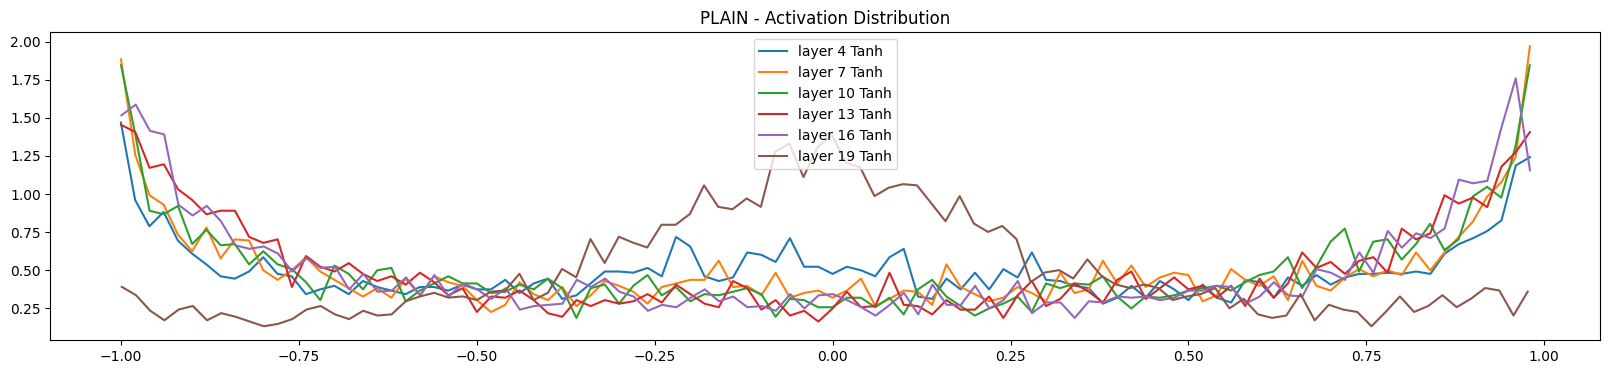

In [51]:
plot_activations(plain_model, "PLAIN")

layer 4 (      Tanh): mean +0.000006, std 1.716352e-03
layer 7 (      Tanh): mean -0.000008, std 1.601546e-03
layer 10 (      Tanh): mean +0.000030, std 1.596385e-03
layer 13 (      Tanh): mean +0.000016, std 1.546409e-03
layer 16 (      Tanh): mean +0.000040, std 1.590845e-03
layer 19 (      Tanh): mean +0.000097, std 3.481596e-03


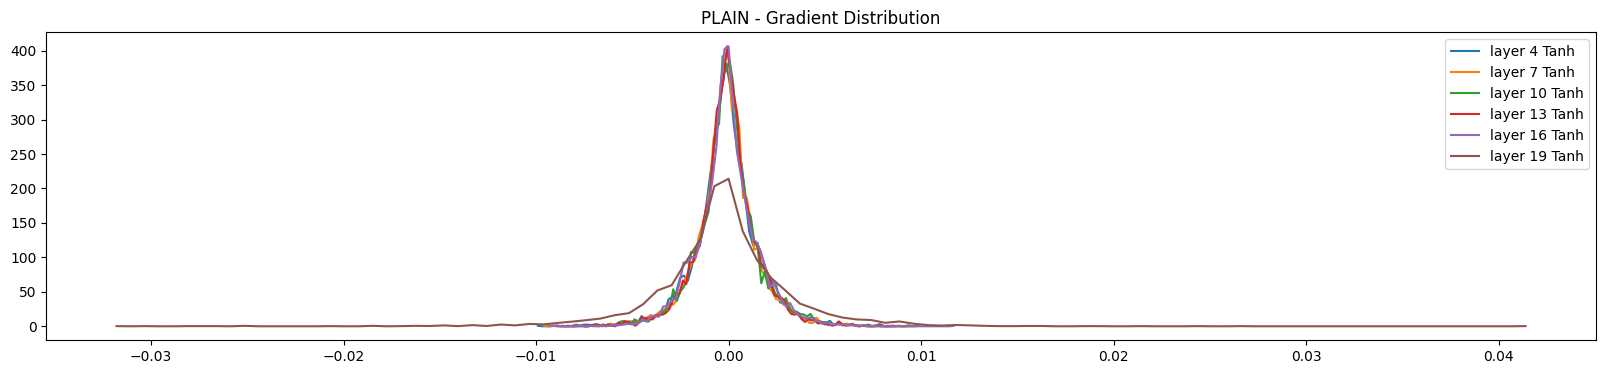

In [52]:
plot_gradients(plain_model, "PLAIN")

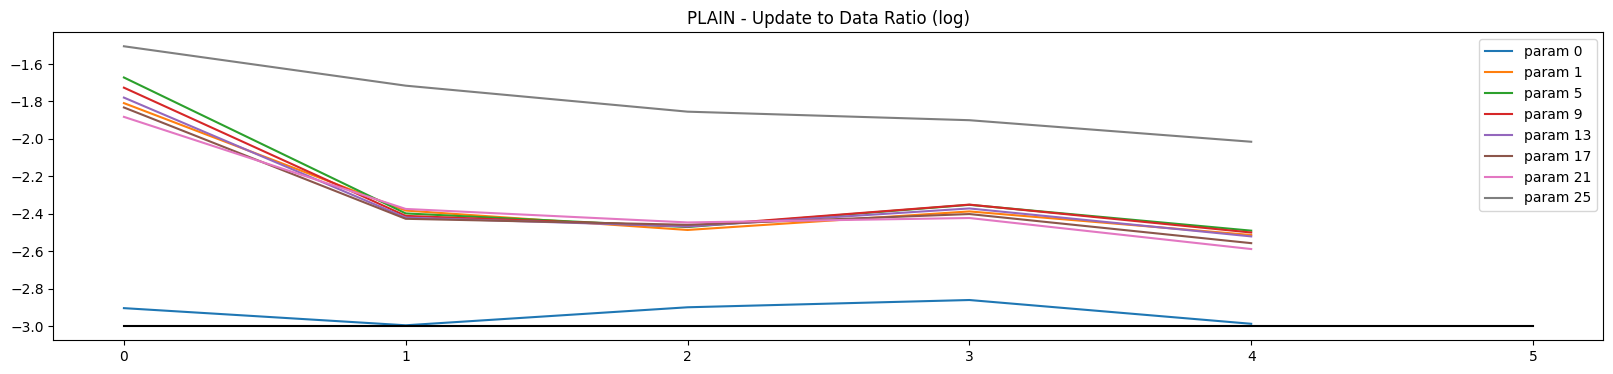

In [53]:
plot_update_ratios(plain_model, "PLAIN", plain_ud)

layer 4 (      Tanh): mean +0.01, std 0.70, saturated: 12.28%
layer 7 (      Tanh): mean -0.02, std 0.70, saturated: 6.86%
layer 10 (      Tanh): mean +0.00, std 0.68, saturated: 3.67%
layer 13 (      Tanh): mean +0.00, std 0.69, saturated: 3.37%
layer 16 (      Tanh): mean +0.03, std 0.70, saturated: 2.75%
layer 19 (      Tanh): mean -0.02, std 0.68, saturated: 5.59%


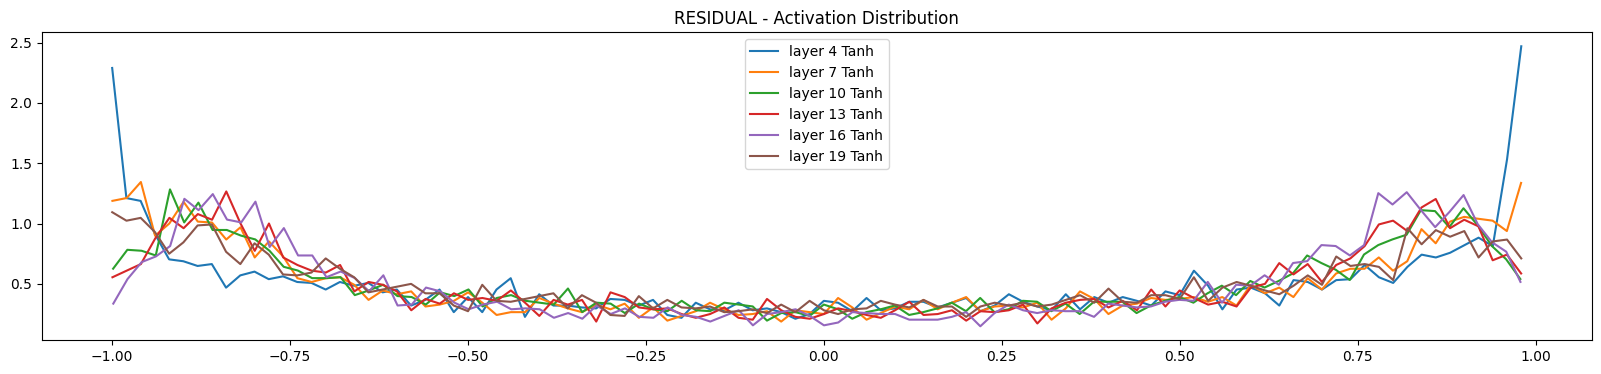

In [54]:
plot_activations(res_model, "RESIDUAL")

layer 4 (      Tanh): mean -0.000026, std 2.714715e-03
layer 7 (      Tanh): mean -0.000026, std 2.370327e-03
layer 10 (      Tanh): mean -0.000008, std 2.269604e-03
layer 13 (      Tanh): mean -0.000000, std 2.257982e-03
layer 16 (      Tanh): mean -0.000002, std 2.252374e-03
layer 19 (      Tanh): mean -0.000004, std 2.653901e-03


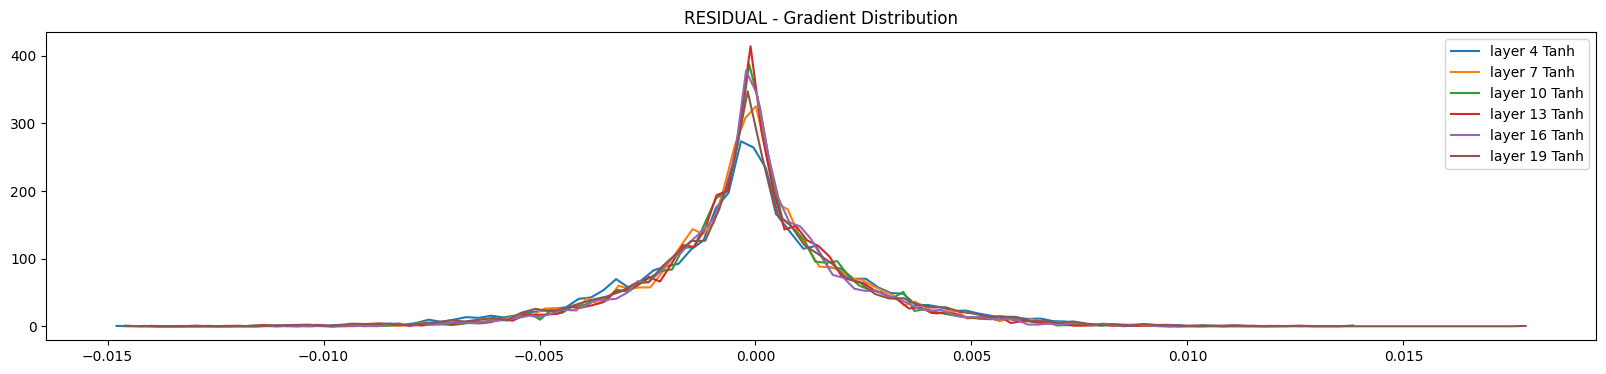

In [57]:
plot_gradients(res_model, "RESIDUAL")

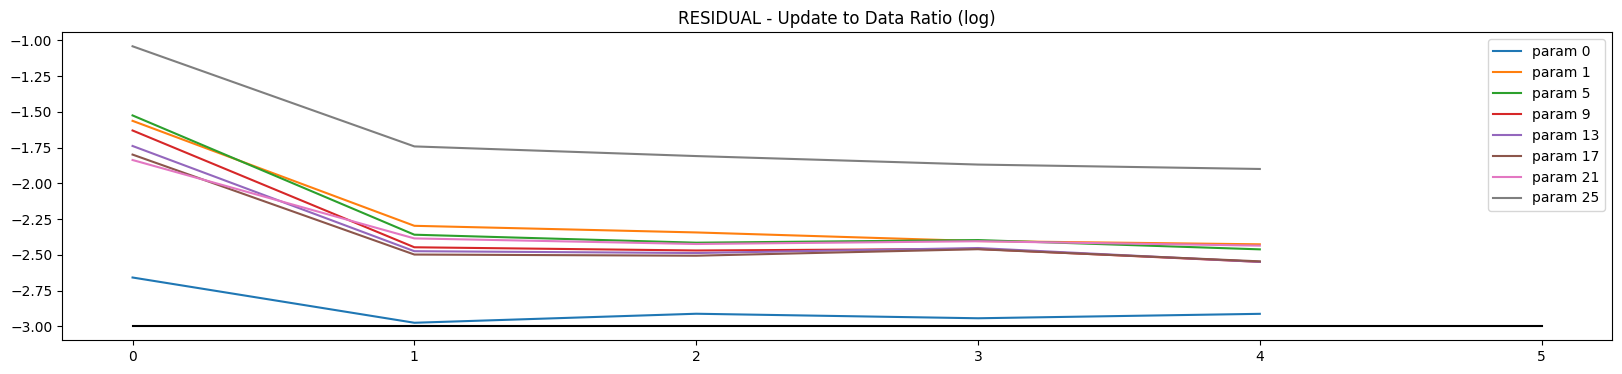

In [59]:
plot_update_ratios(res_model, "RESIDUAL", res_grads)

In [36]:
def get_all_layers(model):
    """Flatten layers including inside Residual blocks"""
    all_layers = []
    for layer in model.layers:
        if isinstance(layer, Residual):
            for sub in layer.layers:
                all_layers.append(sub)
        else:
            all_layers.append(layer)
    return all_layers

def plot_activations(model, name):
    layers = get_all_layers(model)
    plt.figure(figsize=(20, 4))
    legends = []
    for i, layer in enumerate(layers):
        if isinstance(layer, Tanh):
            t = layer.out
            print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % 
                  (i, 'Tanh', t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
            hy, hx = torch.histogram(t.cpu(), density=True)
            plt.plot(hx[:-1].detach(), hy.detach())
            legends.append(f'layer {i} Tanh')
    plt.legend(legends)
    plt.title(f'{name} - Activation Distribution')

def plot_gradients(model, name):
    layers = get_all_layers(model)
    plt.figure(figsize=(20, 4))
    legends = []
    for i, layer in enumerate(layers):
        if isinstance(layer, Tanh):
            t = layer.out.grad
            if t is not None:
                print('layer %d (%10s): mean %+f, std %e' % (i, 'Tanh', t.mean(), t.std()))
                hy, hx = torch.histogram(t.cpu(), density=True)
                plt.plot(hx[:-1].detach(), hy.detach())
                legends.append(f'layer {i} Tanh')
    plt.legend(legends)
    plt.title(f'{name} - Gradient Distribution')

def plot_update_ratios(model, name, ud):
    plt.figure(figsize=(20, 4))
    legends = []
    params = model.parameters()
    for i, p in enumerate(params):
        if p.ndim == 2:
            plt.plot([ud[j][i] for j in range(len(ud))])
            legends.append('param %d' % i)
    plt.plot([0, len(ud)], [-3, -3], 'k')
    plt.legend(legends)
    plt.title(f'{name} - Update to Data Ratio (log)')